In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from statsmodels.tsa.seasonal import STL
import numpy as np
import pywt
import warnings
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import SpectralClustering
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw
from scipy.stats import ks_2samp, anderson_ksamp

warnings.filterwarnings("ignore")

In [7]:
data = pd.read_csv("all_data.csv")

In [8]:
def covert_time(x):
    # time_readable = time.strftime('%Y-%m-%d %H:%M:%S.%f', time.localtime(x))
    local_time = datetime.fromtimestamp(x)
    formatted_time = local_time.strftime('%Y-%m-%d %H:%M:%S.%f')
    return formatted_time
def get_date(x):
    return pd.to_datetime(str(x))

In [9]:
#all_data['datetime'] = pd.to_datetime(all_data["time"], unit='s')
data['datetime'] = data["time"].apply(lambda x: covert_time(x))
data['datetime'] = pd.to_datetime(data['datetime'], format='%Y-%m-%d %H:%M:%S.%f')

In [10]:
# 提取攻击类型
data['attack_type'] = data['prefix'].apply(lambda x: x.split('_')[-2])

unique_attack_types = data['attack_type'].unique()

In [11]:
obs_ls = []
trd_ls = []
sea_ls = []
res_ls = []
def visualize_attack_traffic(data, name, slot):
    """
    Visualize attack traffic for a given attack type, considering both packet length and payload.
    
    :param data: DataFrame containing the attack data
    :param attack_type: The type of attack to visualize
    :param visualize_single_ip: Boolean flag, True to visualize the most frequent single IP, False to visualize total traffic
    """
    data_cpy = data.copy()
    time_min = data_cpy['time'].min()
    specific_attack_data = data_cpy[data_cpy['name'] == name]
    
    if slot == None:
        slot = 0.001
        
    specific_attack_data['group'] = ((specific_attack_data['time'] - time_min) / slot).astype(int)
    filtered_data = specific_attack_data.groupby('group').size()
    
    full_index = pd.RangeIndex(start=filtered_data.index.min(), stop=filtered_data.index.max() + 1)
    filtered_data = filtered_data.reindex(full_index, fill_value=0)
    filtered_data = filtered_data.reset_index()
    filtered_data.columns = ['group', 'num']  # 重命名列

    stl = STL(filtered_data['num'].values, period=4, robust=True)
    stl_result = stl.fit()
    
    observed = stl_result.observed

    # 获取趋势成分
    trend = stl_result.trend
    
    # 获取季节成分
    seasonal = stl_result.seasonal
    
    # 获取残差成分
    resid = stl_result.resid
    
    obs_ls.append(observed)
    trd_ls.append(trend)
    sea_ls.append(seasonal)
    res_ls.append(resid)

In [12]:
data["name"] = data["prefix"] + data["idx"]
for n in data['name'].unique():
    visualize_attack_traffic(data, n, 3)

In [13]:
def normalize_0_1(arrays):
    min_vals = []
    max_vals = []
    normalized_arrays = []
    for arr in arrays:
        min_val = np.min(arr)
        max_val = np.max(arr)
        # 避免分母为零的情况
        if max_val > min_val:
            norm_arr = (arr - min_val) / (max_val - min_val)
            min_vals.append(min_val)
            max_vals.append(max_val)
        else:
            # 如果所有值相同，则直接返回全零数组，或根据情况选择其他适当的处理方式
            norm_arr = np.zeros_like(arr)
            min_vals.append(0)
            max_vals.append(0)
        normalized_arrays.append(norm_arr)
    return normalized_arrays, min_vals, max_vals

In [14]:
normalized_trd_ls, trd_min, trd_max = normalize_0_1(trd_ls)
normalized_sea_ls, sea_min, sea_max = normalize_0_1(sea_ls)

In [17]:
adjusted_sequences = [np.clip(seq, 0.2, 0.8).flatten() for seq in normalized_trd_ls]

In [18]:
def compute_dtw_matrix(sequences):
    n = len(sequences)
    dtw_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            #print(sequences[i].shape,sequences[j].shape)
            distance, _ = fastdtw(sequences[i], sequences[j], dist=2)
            dtw_matrix[i, j] = dtw_matrix[j, i] = distance
    return dtw_matrix

dtw_matrix = compute_dtw_matrix(adjusted_sequences)

In [19]:
# 步骤3: 使用MDS算法将序列嵌入到2D空间
mds = MDS(n_components=12, dissimilarity='precomputed', random_state=42)
embeddings = mds.fit_transform(dtw_matrix)

In [15]:
kmeans = KMeans(n_clusters=4, random_state=42)

# 初始化DBSCAN
# dbscan = DBSCAN(eps=3, min_samples=2)

# 初始化谱聚类
spectral = SpectralClustering(n_clusters=4, affinity='nearest_neighbors',
                              assign_labels='kmeans', random_state=42)

kmeans.fit(embeddings)

# 打印中心点和标签
print("Cluster centers:", kmeans.cluster_centers_)
print("Kmeans Labels:", kmeans.labels_)

spectral.fit(embeddings)
# 打印标签
print("Spectral Labels:", spectral.labels_)

Cluster centers: [[  0.13224021   5.65169722   0.555896    -8.83414664  -5.82925312
    1.11019361  -7.88634689  -4.0754012   -4.65304447  -4.74689542
    3.86227492   2.68094541]
 [  1.79037756  -3.56175657   1.15206911   5.26210134   3.42771329
   -1.60237345   5.95764646   1.91574463  -2.56660267   6.63116644
   -2.95544568   2.42191443]
 [  2.83155445   6.64679099  -0.93743378 -42.69582268  -9.73960284
   13.62914737  -7.71800138 -13.31695328 -13.08588696 -18.47317669
    9.03514806  -0.25784219]
 [ -1.56766134  -1.71012062  -0.58824172   9.78633373   2.50987656
   -2.53191363   1.54956941   3.40042157   5.83959035   2.36494571
   -1.87164559  -2.16393962]]
Kmeans Labels: [3 3 1 1 1 3 1 1 3 1 1 3 3 1 1 3 3 1 3 1 1 3 3 3 3 3 0 0 1 3 3 2 3 0 2 3 2
 2 3 0 2 3 2 0 3 3 3 3 3 3 2 3 1 1 3 0 3 3 0 0 1 3 3 1 1 3 1 0 0 3 3 1 3 3
 0 3 3 3 3 3 3 1 3 3 1 0 0 0 1 3 1 1 1 0 2 3 1 3 3 1 3 3 1 2 2 0 1 2 2 2 3
 1 3 3 2 3 0 0 0 3 3 0 0 0 0 3 1 0 3 3 3 3 3 1 3 3]
Spectral Labels: [2 2 0 0 0 3 0 0 3 0 

In [20]:
kmeans = KMeans(n_clusters=4, random_state=42)

# 初始化DBSCAN
# dbscan = DBSCAN(eps=3, min_samples=2)

# 初始化谱聚类
spectral = SpectralClustering(n_clusters=4, affinity='nearest_neighbors',
                              assign_labels='kmeans', random_state=42)

kmeans.fit(embeddings)

# 打印中心点和标签
print("Cluster centers:", kmeans.cluster_centers_)
print("Kmeans Labels:", kmeans.labels_)

spectral.fit(embeddings)
# 打印标签
print("Spectral Labels:", spectral.labels_)

Cluster centers: [[  0.13224021   5.65169722   0.555896    -8.83414664  -5.82925312
    1.11019361  -7.88634689  -4.0754012   -4.65304447  -4.74689542
    3.86227492   2.68094541]
 [  1.79037756  -3.56175657   1.15206911   5.26210134   3.42771329
   -1.60237345   5.95764646   1.91574463  -2.56660267   6.63116644
   -2.95544568   2.42191443]
 [  2.83155445   6.64679099  -0.93743378 -42.69582268  -9.73960284
   13.62914737  -7.71800138 -13.31695328 -13.08588696 -18.47317669
    9.03514806  -0.25784219]
 [ -1.56766134  -1.71012062  -0.58824172   9.78633373   2.50987656
   -2.53191363   1.54956941   3.40042157   5.83959035   2.36494571
   -1.87164559  -2.16393962]]
Kmeans Labels: [3 3 1 1 1 3 1 1 3 1 1 3 3 1 1 3 3 1 3 1 1 3 3 3 3 3 0 0 1 3 3 2 3 0 2 3 2
 2 3 0 2 3 2 0 3 3 3 3 3 3 2 3 1 1 3 0 3 3 0 0 1 3 3 1 1 3 1 0 0 3 3 1 3 3
 0 3 3 3 3 3 3 1 3 3 1 0 0 0 1 3 1 1 1 0 2 3 1 3 3 1 3 3 1 2 2 0 1 2 2 2 3
 1 3 3 2 3 0 0 0 3 3 0 0 0 0 3 1 0 3 3 3 3 3 1 3 3]
Spectral Labels: [2 2 0 0 0 3 0 0 3 0 

In [29]:
labels = spectral.labels_ 

# 按类别组织序列
from collections import defaultdict

class_dict = defaultdict(list)

# 按标签分类存储序列
for seq, label in zip(normalized_trd_ls, labels):
    class_dict[label].append(seq)

# 拼接每个类别的序列，每个序列间以8个0分隔
concatenated_sequences_by_class = {}

for label, sequences in class_dict.items():
    # 拼接序列，每两个序列之间插入8个零
    dfs_len = []
    dfs_no = []
    i = 0
    concatenated_sequence = sequences[0]
    dfs_len.append(len(sequences[0]))
    dfs_no.append(i)
    for seq in sequences[1:]:
        i+=1
        concatenated_sequence = np.concatenate([concatenated_sequence, seq])
        dfs_len.append(len(seq))
        dfs_no.append(i)
    concatenated_sequences_by_class[label] = concatenated_sequence
    seqno_data = pd.DataFrame({
        'len': dfs_len,
        'no': dfs_no
    })
    #seqno_data.to_csv(f"data_syn\\no_info\\noinfo_label_{label}.csv")

# 输出每个类别的拼接结果
for label, seq in concatenated_sequences_by_class.items():
    print(f"Label {label}: {seq}")

Label 2: [0.21412058 0.19300143 0.17132351 ... 0.40290914 0.40298637 0.4030886 ]
Label 0: [0.72126189 0.64338017 0.56503195 ... 0.15468484 0.15468453 0.15468418]
Label 3: [0.09116291 0.09114749 0.09113441 ... 0.14986268 0.14986268 0.14986268]
Label 1: [0.90007864 0.80446556 0.70885247 ... 0.47228796 0.47224471 0.47220075]


In [21]:
for label, seq in concatenated_sequences_by_class.items():
    data_0 = pd.DataFrame({'0':seq})
    data_0.to_csv(f"label_{label}.csv")

1. 每个label会输出四个文件：centroid，segment，subseq和label
2. 我需要根据每个label的这四个文件，将四个类的season生成这四个文件，label需要做额外处理
3. 

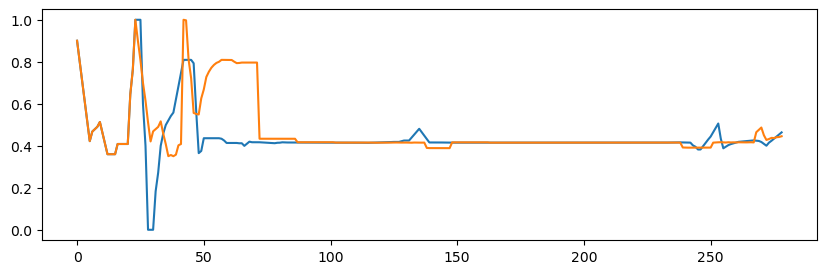

In [102]:
plt.figure(figsize=(10, 3))
plt.plot(class_dict[1][0])
plt.plot(np.load("data_syn/l15-30-ep1000-dw0.98-self/label_1/syn_idx0.npy"))
#plt.plot(np.load("data_syn/l15-30-ep1000-dw0.98-self/syn_idx0.npy"))
#plt.plot(np.load("data_syn/label1_l15-30-ep1000-dw0.98/syn_idx2.npy"))

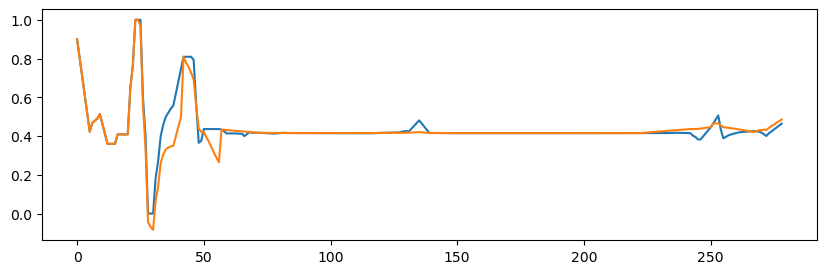

In [150]:
plt.figure(figsize=(10, 3))
plt.plot(class_dict[1][0])
#plt.plot(np.load("data_syn/l15-30-ep1000-dw0.98-self/label_1/syn_idx0.npy"))
plt.plot(np.load("data_syn/l15-30-ep1000-dw0.98-self/syn_idx0.npy"))
#plt.plot(np.load("data_syn/label1_l15-30-ep1000-dw0.98/syn_idx2.npy"))

In [116]:
class_dict[1][1]

array([5.21316248e-01, 5.21316135e-01, 5.21316034e-01, 5.21315936e-01,
       5.21315827e-01, 5.21315719e-01, 5.21315630e-01, 5.21315558e-01,
       5.21315520e-01, 5.21315490e-01, 5.21315524e-01, 5.21315563e-01,
       5.21315565e-01, 5.21315569e-01, 5.21315586e-01, 5.21315596e-01,
       5.21315596e-01, 5.21315601e-01, 5.21315606e-01, 5.21315609e-01,
       5.21315611e-01, 5.21315612e-01, 5.21315611e-01, 5.21315610e-01,
       5.21315610e-01, 5.21315610e-01, 5.21315609e-01, 5.21315609e-01,
       5.21315608e-01, 5.21315608e-01, 5.21315608e-01, 5.21315608e-01,
       5.21315608e-01, 5.21315608e-01, 5.21315608e-01, 5.21315608e-01,
       5.21315608e-01, 5.21315608e-01, 5.21315608e-01, 5.21315608e-01,
       5.21315608e-01, 5.21315608e-01, 5.21315608e-01, 5.21315608e-01,
       5.21315608e-01, 5.21315608e-01, 5.21315608e-01, 5.21315608e-01,
       5.21315608e-01, 5.21315608e-01, 5.21315608e-01, 5.21315608e-01,
       5.21315608e-01, 5.21315608e-01, 5.21315608e-01, 5.21315608e-01,
      

In [68]:
np.load("data_syn/label1_l15-30-ep1000-dw0.98/syn_idx0.npy")

array([], dtype=float64)

In [40]:
len(class_dict[2])

29

In [143]:
# 生成两组样本数据
data1 = class_dict[1][1][:100]
data2 = np.load("data_syn/l15-30-ep1000-dw0.98-self/syn_idx1.npy")[:100]

In [148]:
data1

array([0.52131625, 0.52131614, 0.52131603, 0.52131594, 0.52131583,
       0.52131572, 0.52131563, 0.52131556, 0.52131552, 0.52131549,
       0.52131552, 0.52131556, 0.52131556, 0.52131557, 0.52131559,
       0.5213156 , 0.5213156 , 0.5213156 , 0.52131561, 0.52131561,
       0.52131561, 0.52131561, 0.52131561, 0.52131561, 0.52131561,
       0.52131561, 0.52131561, 0.52131561, 0.52131561, 0.52131561,
       0.52131561, 0.52131561, 0.52131561, 0.52131561, 0.52131561,
       0.52131561, 0.52131561, 0.52131561, 0.52131561, 0.52131561,
       0.52131561, 0.52131561, 0.52131561, 0.52131561, 0.52131561,
       0.52131561, 0.52131561, 0.52131561, 0.52131561, 0.52131561,
       0.52131561, 0.52131561, 0.52131561, 0.52131561, 0.52131561,
       0.52131561, 0.52131561, 0.52131561, 0.52131561, 0.52131561,
       0.52131561, 0.52131561, 0.52131561, 0.52131561, 0.52131561,
       0.52131561, 0.52131561, 0.52131561, 0.52131561, 0.52131561,
       0.52131561, 0.52131561, 0.52131561, 0.52131561, 0.52131

In [149]:
# 计算KS统计量
ks_stat = ks_2samp(data1, data2)
# 对KS统计量应用下限0和上限1
#ks_stat = max(0, min(1, ks_stat))

# 计算AD统计量
# 注意：anderson_ksamp要求输入为列表形式的多个样本集
ad_stat = anderson_ksamp([data1, data2])

# 对AD统计量应用下限0.01和上限0.25
#ad_stat = max(0.01, min(0.25, ad_stat))

# 打印结果
print(f"KS statistic: {ks_stat[1]:.3f}")
print(f"AD statistic: {ad_stat[2]:.3f}")

KS statistic: 0.000
AD statistic: 0.001


In [135]:
 ks_2samp(data1, data2)

KstestResult(statistic=0.2090032154340836, pvalue=2.3281674447134576e-06, statistic_location=0.15462256940315364, statistic_sign=1)

In [136]:
sum(data1)

79.31446309586175

In [137]:
sum(data2)

87.16902035966146

In [144]:
fastdtw(data1, data2, dist=2)

(16.726622619376354,
 [(0, 0),
  (1, 1),
  (2, 2),
  (3, 3),
  (4, 4),
  (5, 5),
  (6, 6),
  (7, 7),
  (8, 8),
  (9, 9),
  (10, 10),
  (11, 11),
  (12, 12),
  (13, 13),
  (14, 14),
  (15, 15),
  (16, 16),
  (17, 17),
  (18, 18),
  (19, 19),
  (20, 20),
  (21, 21),
  (22, 22),
  (22, 23),
  (22, 24),
  (22, 25),
  (22, 26),
  (22, 27),
  (22, 28),
  (22, 29),
  (22, 30),
  (22, 31),
  (22, 32),
  (22, 33),
  (22, 34),
  (22, 35),
  (22, 36),
  (22, 37),
  (22, 38),
  (22, 39),
  (22, 40),
  (22, 41),
  (22, 42),
  (22, 43),
  (23, 44),
  (24, 45),
  (25, 46),
  (26, 47),
  (27, 47),
  (28, 47),
  (29, 48),
  (30, 49),
  (31, 50),
  (32, 51),
  (33, 51),
  (34, 52),
  (35, 53),
  (36, 54),
  (37, 55),
  (37, 56),
  (38, 57),
  (39, 58),
  (40, 59),
  (41, 60),
  (42, 61),
  (42, 62),
  (43, 63),
  (44, 64),
  (45, 64),
  (46, 64),
  (47, 65),
  (48, 65),
  (49, 65),
  (50, 66),
  (51, 67),
  (52, 68),
  (53, 69),
  (54, 70),
  (55, 71),
  (56, 72),
  (57, 73),
  (58, 74),
  (59, 75),
  (

In [145]:
np.inf

inf

In [148]:
#dist_rnds = np.full(len(class_dict[0]), np.inf)
dist_selfs = np.full(len(class_dict[0]), np.inf)
dist_oths = np.full(len(class_dict[0]), np.inf)
for i in range(len(class_dict[0])):
    data1 = np.load(f"data_syn/l15-30-ep1000-dw0.98-self/label_0/syn_idx{i}.npy")
#    rnd = np.random.rand(len(data1))
#    dist_rnd, _ =  fastdtw(data1, rnd, dist=2)
#    dist_rnds[i] = dist_rnd
    for j in range(len(class_dict[0])):
        # 生成两组样本数据
        data2 = class_dict[0][j]
        dist, _ = fastdtw(data1, data2, dist=2)
        if i == j:
            dist_selfs[i] = dist
        else:
            if dist < dist_oths[i]:
                dist_oths[i] = dist
            else:
                pass

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


In [164]:
rd = []

In [177]:
for i in range(len(class_dict[0])):
    data1 = class_dict[0][i]
    rnd = np.random.rand(len(data1))
    dist_rnd, _ =  fastdtw(data1, rnd, dist=2)
    rd.append(dist_rnd)

In [172]:
np.mean(rd)

85.09828317031969

In [207]:
dds = []
for i in range(len(class_dict[0])):
    data1 = np.load(f"data_syn/l15-30-ep1000-dw0.98-self/label_0_cons/syn_idx{i}.npy")
    data2 = class_dict[0][i]
    dist_rnd, _ =  fastdtw(data1, data2, dist=2)
    dds.append(dist_rnd)

In [208]:
np.mean(dds)

80.30390096920279

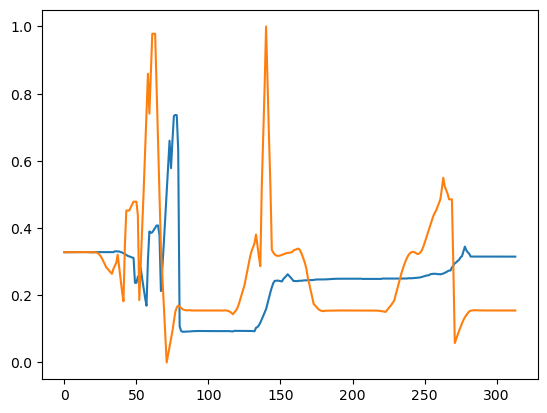

In [210]:
plt.plot( np.load(f"data_syn/l15-30-ep1000-dw0.98-self/label_0_cons/syn_idx{i}.npy"))
plt.plot(class_dict[0][i])

In [186]:
class_dict[2][21]

array([0.        , 0.14285714, 0.28571429, 0.42857143, 0.57142857,
       0.71428571, 0.85714286, 1.        ])

In [187]:
#dist_rnds = np.full(len(class_dict[0]), np.inf)

dist_oths = np.full(len(class_dict[0]), np.inf)
for i in range(10):
    print(i)
    data1 = np.load(f"data_syn/l15-30-ep1000-dw0.98-self/label_1/syn_idx{i}.npy")
#    rnd = np.random.rand(len(data1))
#    dist_rnd, _ =  fastdtw(data1, rnd, dist=2)
#    dist_rnds[i] = dist_rnd
    for j in range(len(class_dict[0])):
        # 生成两组样本数据
        data2 = class_dict[0][j]
        dist, _ = fastdtw(data1, data2, dist=2)
        if dist < dist_oths[i]:
            dist_oths[i] = dist
        else:
            pass

0
1
2
3
4
5
6
7
8
9


In [190]:
np.mean(dist_oths[:10])

47.19346451720124

In [189]:
dist_oths

array([46.18230209, 50.39533638, 52.91177124, 59.35754898, 42.81182667,
       43.75426609, 48.57477637, 37.13366145, 37.37107095, 53.44208495,
               inf,         inf,         inf,         inf,         inf,
               inf,         inf,         inf,         inf,         inf,
               inf,         inf,         inf,         inf,         inf,
               inf,         inf,         inf,         inf,         inf])

In [38]:
data1 = class_dict[0][1]

NameError: name 'class_dict' is not defined

In [201]:
copied_array = data1.copy()

# 随机选择一个起始索引，确保连续30个值不会超出数组边界
start_index = 0

# 将选定的连续30个值设置为0
copied_array[start_index:start_index + 100] = 0

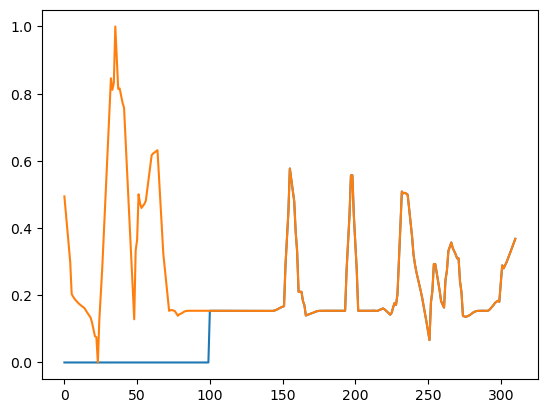

In [202]:
plt.plot(copied_array)
plt.plot(data1)

In [203]:
dist_rnd, _ =  fastdtw(data1, copied_array, dist=2)
dist_rnd

25.25605798934401

In [205]:
len(class_dict[1])

16

In [14]:
trd_min

[-0.05439938887219256,
 -0.39051261193551606,
 -0.3039520736401945,
 -0.3816459555569562,
 -0.08122013679358486,
 -0.42284527076321937,
 -0.27069169789360736,
 -0.07797901618457734,
 -0.376308259502533,
 -0.06695012249306644,
 -0.2092964452602791,
 -0.06115864874412078,
 -0.122714319274613,
 -0.1518091630848924,
 -0.06830475466211396,
 -1.072619939927751,
 -0.010582425420431155,
 -0.12742221245126853,
 -0.03934383591099699,
 -0.5144070070646454,
 -0.14693219474858246,
 -0.02619793018648065,
 -0.1474409583016163,
 -0.17005148832697609,
 -0.11062216080820941,
 -0.27181101473982905,
 -8.866269811727332,
 -7.2882971600502735,
 -0.7228812551725354,
 -1.8128793154181577,
 -1.7015646313056803,
 -3.6159508315040343,
 -0.11875679884523588,
 -8.97872080557448,
 -4.285877068238864,
 -1.2484187579920654,
 -211.0701860709873,
 -6.472053500048871,
 -2.1267700895386294,
 -3.9148951903724787,
 -6.752136432782132,
 -0.01771088042119506,
 -24.11633646041003,
 -12.03790989308157,
 -3.8839031012344543,
 -

In [15]:
trd_max

[26.247740926335666,
 6.757615161584737,
 1.5757641786710703,
 2.098635557649445,
 1.208159556274042,
 4.217593544878824,
 2.0456211232262933,
 1.7476981772732523,
 2.3186967593856087,
 1.7808140907574397,
 1.6775466678928845,
 1.2191773687727243,
 2.32214228559552,
 1.6988605031547646,
 1.283787649810251,
 4.422536406977372,
 5.277433876946433,
 3.1740185568291013,
 2.9735641209906216,
 1.8453586235009813,
 1.4054449513996055,
 3.02190179010289,
 1.5666388007905647,
 3.1963922763575803,
 2.8998429623563826,
 1.7921261230210948,
 12.500934307770748,
 16.842508002986868,
 2.5092295132363267,
 14.034943503789115,
 10.687662675986516,
 3.320252066720943,
 1.720650215366497,
 19.39317457175963,
 2.521364493068009,
 11.081416683076682,
 94.52046768343482,
 6.536339872871886,
 17.06418362250766,
 6.516857928527942,
 5.69523960864025,
 16.517294855127144,
 19.661576957849416,
 13.59660241686383,
 17.191989165268094,
 13.29345495540064,
 10.106388744998615,
 9.39248491016421,
 2.61127943402421

In [ ]:
trd_min

In [30]:
def store_min_max(mins, maxs, labels, name='trd'):
    mins_lab = [[] for _ in range(len(set(labels)))]
    maxs_lab = [[] for _ in range(len(set(labels)))]
    for idx, lab in enumerate(labels):
        mins_lab[lab].append(mins[idx])
        maxs_lab[lab].append(maxs[idx])
    #for idx in range(len(mins_lab)):
    #    np.save(f"data_syn\minmax\min_{name}_label_{idx}.npy", np.array(mins_lab[idx]))
    #    np.save(f"data_syn\minmax\max_{name}_label_{idx}.npy", np.array(maxs_lab[idx]))
    return np.array(mins_lab, dtype='object'), np.array(maxs_lab, dtype='object')

In [31]:
trd_mins_lab, trd_maxs_lab = store_min_max(trd_min, trd_max, spectral.labels_)
trd_sea_ls, trd_res_ls = store_min_max(sea_ls, res_ls, spectral.labels_)

In [22]:
trd_maxs_lab

array([list([1.5757641786710703, 2.098635557649445, 1.208159556274042, 2.0456211232262933, 1.7476981772732523, 1.7808140907574397, 1.6775466678928845, 1.6988605031547646, 1.283787649810251, 3.1740185568291013, 1.8453586235009813, 1.4054449513996055, 2.5092295132363267, 8.91045729035449, 10.842643932534632, 3.447301417345261, 2.567254989536103, 8.490335839180759, 3.7227945680951664, 6.890606018256837, 2.4081839316609357, 4.591015994479124, 1.4346476525970002, 2.403216955688845, 2.130243755064119, 3.2248186729871526, 3.9395317933940994, 2.0074135951783108, 17.280178622261644, 1.2165257583113698]),
       list([12.500934307770748, 3.320252066720943, 2.521364493068009, 94.52046768343482, 6.536339872871886, 5.69523960864025, 19.661576957849416, 13.59660241686383, 3.0277074057175284, 6.178432101385113, 46.4311447530178, 2.7907934807483246, 5.922030746975688, 7.487502726835658, 22.865714199043246, 10.707304957184475]),
       list([26.247740926335666, 6.757615161584737, 16.842508002986868, 19

In [40]:
sea_ls

[array([-2.44255934e+00,  3.04827078e+00,  3.19740993e-01, -1.01364132e+00,
        -1.76806256e+00,  2.29560719e+00,  1.41519636e-01, -7.46336226e-01,
        -1.11939375e+00,  1.55678251e+00, -1.51501388e-02, -4.94093673e-01,
        -4.52533916e-01,  8.11832815e-01, -1.15981437e-01, -1.55654777e-01,
        -9.97769949e-02,  3.42653706e-02, -9.73485095e-03,  7.75812690e-03,
         5.45699320e-03,  1.48251145e-02,  1.77886716e-03,  5.57142472e-03,
         3.03948150e-03,  1.47685815e-03,  1.76316416e-03,  1.63747826e-03,
         6.74084436e-04,  2.33681545e-05, -4.04884800e-04, -6.08729408e-04,
        -7.36958560e-05,  5.52896084e-04, -7.31920095e-04, -2.59201687e-03,
         1.98942943e-03,  1.04556508e-02,  1.13446474e-02,  3.25589332e-03,
         2.27793796e-03, -3.04834673e-02,  7.86232805e-02,  6.24152408e-02,
         3.34895378e-02, -3.08622463e-01,  2.70474569e-01,  2.32427427e-01,
         1.17139737e-01, -1.01491010e+00,  5.16953855e-01,  2.73232367e-01,
         3.2

In [32]:
sea_ls, res_ls, trd_min, trd_max
trd_mins_lab, trd_max_lab
print()

NameError: name 'trd_max_lab' is not defined

In [24]:
import os
import random

In [25]:
seq_gen_dir = "0709_seqgen"

In [26]:
nlabels = len(os.listdir(seq_gen_dir))

In [27]:
def add_min_length_arrays(tsea, ttrd, tres):
    # 确定三个数组中的最小长度
    min_length = min(len(tsea), len(ttrd), len(tres))
    
    # 截取每个数组到最小长度
    tsea_cut = tsea[:min_length]
    ttrd_cut = ttrd[:min_length]
    tres_cut = tres[:min_length]
    
    # 计算对应位置的元素相加
    result = tsea_cut + ttrd_cut + tres_cut
    
    return result

In [33]:
gen_seq_dict = {
    "label_0": [],
    "label_1": [],
    "label_2": [],
    "label_3": []
}
for l in range(nlabels):
    cur_dir = f"label_{l}"
    cur_path = os.path.join(seq_gen_dir, cur_dir)
    cur_trd_min = trd_mins_lab[l]
    cur_trd_max = trd_maxs_lab[l]
    cur_sea = trd_sea_ls[l]
    cur_res = trd_res_ls[l]
    
    for idx, path in enumerate(os.listdir(cur_path)):
        if l == 2 and (idx == 21 or idx == 22):
            gen_seq_dict[f"label_{l}"].append(class_dict[l][idx])
        ttrd_path = os.path.join(cur_path, path)
        
        ttmin = cur_trd_min[idx]
        ttmax = cur_trd_max[idx]
        tsea = cur_sea[idx]
        tres = cur_res[idx]
        ttrd = np.load(ttrd_path) * (ttmax-ttmin) + ttmin
        
        tseq = add_min_length_arrays(tsea, ttrd, tres)
        tseq = np.floor(tseq + 0.5)
        
        gen_seq_dict[f"label_{l}"].append(tseq)

In [34]:
def get_tuple(data, name, mode):
    data_cpy = data.copy()
    specific_attack_data = data_cpy[data_cpy['name'] == name]
    time_min = specific_attack_data['time'].min()
    time_max = specific_attack_data['time'].max()
    return (f"label_{mode}", name.split('_')[-3], time_min, time_max-time_min)

In [35]:
chain = []
for idx, n in enumerate(data['name'].unique()):
    cur_tuple = get_tuple(data, n, spectral.labels_[idx])
    chain.append(cur_tuple)
#chain = sorted(chain, key = lambda x:x[-2])

In [139]:
all_st = list(set([c[0] for c in chain]))
all_at = list(set([c[1] for c in chain]))

In [140]:
random.choice(all_st)

'label_0'

In [141]:
def generate_new_chain(chain):
    new_chain = []
    for item in chain:
        # 保持前两个元素不变，第三个元素设置为0-400的随机数
        new_tuple = (random.choice(all_st), random.choice(all_at), random.randint(0, 400))
        new_chain.append(new_tuple)
    return new_chain

In [69]:
def generate_new_chain(chain):
    new_chain = []
    for item in chain:
        # 保持前两个元素不变，第三个元素设置为0-400的随机数
        new_tuple = (item[0], item[1], random.randint(0, 400))
        new_chain.append(new_tuple)
    return new_chain

In [72]:
new_chain = generate_new_chain(chain)

In [73]:
new_chain

[('label_2', 'TCPConnectionFlood', 3),
 ('label_3', 'ACKFlood', 20),
 ('label_3', 'ACKFlood', 136),
 ('label_1', 'ACKFlood', 78),
 ('label_3', 'ACKFlood', 35),
 ('label_2', 'ACKFlood', 397),
 ('label_3', 'ACKFlood', 259),
 ('label_0', 'ACKFlood', 145),
 ('label_3', 'TCPConnectionFlood', 133),
 ('label_3', 'SYNFlood', 271),
 ('label_1', 'ACKFlood', 288),
 ('label_3', 'ACKFlood', 73),
 ('label_2', 'ACKFlood', 400),
 ('label_3', 'ACKFlood', 204),
 ('label_0', 'ACKFlood', 165),
 ('label_0', 'SYNFlood', 12),
 ('label_1', 'ACKFlood', 45),
 ('label_0', 'ACKFlood', 296),
 ('label_3', 'ACKFlood', 295),
 ('label_1', 'ACKFlood', 202),
 ('label_0', 'ACKFlood', 194),
 ('label_2', 'ACKFlood', 391),
 ('label_3', 'ACKFlood', 21),
 ('label_0', 'SYNFlood', 294),
 ('label_3', 'SYNFlood', 61),
 ('label_2', 'ACKFlood', 84),
 ('label_2', 'TCPConnectionFlood', 4),
 ('label_1', 'ACKFlood', 29),
 ('label_1', 'SYNFlood', 356),
 ('label_3', 'FilterAttack', 288),
 ('label_2', 'ACKFlood', 185),
 ('label_3', 'FINRS

In [42]:
pcaps_gen_dir = "0702_gen\generated_nprint"
attack_files = os.listdir(pcaps_gen_dir)
all_attacks = set([name.split("_")[0] for name in attack_files])

In [43]:
all_attacks

{'193951',
 '233234',
 'ACKFlood',
 'FINRSTFlood',
 'FilterAttack',
 'HTTPConnectionFlood',
 'ICMPFlood',
 'SYN-ACKFlood',
 'SYNFlood',
 'TCPConnectionFlood'}

In [44]:
seeds = [1234, -1, 3407]

In [45]:
attack_files

['193951_1_-1.nprint',
 '193951_1_1234.nprint',
 '193951_1_3407.nprint',
 '193951_2_-1.nprint',
 '193951_2_1234.nprint',
 '193951_2_3407.nprint',
 '193951_3_-1.nprint',
 '193951_3_1234.nprint',
 '193951_3_3407.nprint',
 '193951_4_-1.nprint',
 '193951_4_1234.nprint',
 '193951_4_3407.nprint',
 '193951_5_-1.nprint',
 '193951_5_1234.nprint',
 '193951_5_3407.nprint',
 '233234_10_-1.nprint',
 '233234_10_1234.nprint',
 '233234_10_3407.nprint',
 '233234_1_-1.nprint',
 '233234_1_1234.nprint',
 '233234_1_3407.nprint',
 '233234_2_-1.nprint',
 '233234_2_1234.nprint',
 '233234_2_3407.nprint',
 '233234_3_-1.nprint',
 '233234_3_1234.nprint',
 '233234_3_3407.nprint',
 '233234_4_-1.nprint',
 '233234_4_1234.nprint',
 '233234_4_3407.nprint',
 '233234_5_-1.nprint',
 '233234_5_1234.nprint',
 '233234_5_3407.nprint',
 '233234_6_-1.nprint',
 '233234_6_1234.nprint',
 '233234_6_3407.nprint',
 '233234_7_-1.nprint',
 '233234_7_1234.nprint',
 '233234_7_3407.nprint',
 '233234_8_-1.nprint',
 '233234_8_1234.nprint',


In [46]:
def read_data_seq(attack_type, seeds, drop_first=True):
    datas = []
    
    for s in seeds:
        i = 1
        while True:
            find = 0
            prefix = f"{attack_type}_{i}_{s}"
            #print(prefix)
            for file in attack_files:
                if prefix in file:
                    find = 1
                    print(prefix, file)
                    file_path = os.path.join(pcaps_gen_dir, file)
                    data = pd.read_csv(file_path).drop("Unnamed: 0", axis=1)
                    data = data[~(data == -1).all(axis=1)]
                    data["label"] = attack_type
                    datas.append(data)
                    i+=1
            if find == 0:
                break
                    
    datas = pd.concat(datas, ignore_index=True)
    
    return datas

In [47]:
attack_nprint_dict = {}
for a in all_attacks:
    attack_nprint_dict[a] = read_data_seq(a, seeds)

TCPConnectionFlood_1_1234 TCPConnectionFlood_1_1234.nprint
TCPConnectionFlood_2_1234 TCPConnectionFlood_2_1234.nprint
TCPConnectionFlood_3_1234 TCPConnectionFlood_3_1234.nprint
TCPConnectionFlood_4_1234 TCPConnectionFlood_4_1234.nprint
TCPConnectionFlood_5_1234 TCPConnectionFlood_5_1234.nprint
TCPConnectionFlood_1_-1 TCPConnectionFlood_1_-1.nprint
TCPConnectionFlood_2_-1 TCPConnectionFlood_2_-1.nprint
TCPConnectionFlood_3_-1 TCPConnectionFlood_3_-1.nprint
TCPConnectionFlood_4_-1 TCPConnectionFlood_4_-1.nprint
TCPConnectionFlood_5_-1 TCPConnectionFlood_5_-1.nprint
TCPConnectionFlood_1_3407 TCPConnectionFlood_1_3407.nprint
TCPConnectionFlood_2_3407 TCPConnectionFlood_2_3407.nprint
TCPConnectionFlood_3_3407 TCPConnectionFlood_3_3407.nprint
TCPConnectionFlood_4_3407 TCPConnectionFlood_4_3407.nprint
TCPConnectionFlood_5_3407 TCPConnectionFlood_5_3407.nprint
HTTPConnectionFlood_1_1234 HTTPConnectionFlood_1_1234.nprint
HTTPConnectionFlood_1_-1 HTTPConnectionFlood_1_-1.nprint
HTTPConnectionFlo

FINRSTFlood_1_-1 FINRSTFlood_1_-1.nprint
FINRSTFlood_2_-1 FINRSTFlood_2_-1.nprint
FINRSTFlood_1_3407 FINRSTFlood_1_3407.nprint
FINRSTFlood_2_3407 FINRSTFlood_2_3407.nprint


In [203]:
all_attacks

{'193951',
 '233234',
 'ACKFlood',
 'FINRSTFlood',
 'FilterAttack',
 'HTTPConnectionFlood',
 'ICMPFlood',
 'SYN-ACKFlood',
 'SYNFlood',
 'TCPConnectionFlood'}

In [204]:
nprint_idx_dict = {}
for a in all_attacks:
    nprint_idx_dict[a] = 0

In [205]:
nprint_idx_dict

{'TCPConnectionFlood': 0,
 'HTTPConnectionFlood': 0,
 'ACKFlood': 0,
 '233234': 0,
 '193951': 0,
 'SYN-ACKFlood': 0,
 'FilterAttack': 0,
 'SYNFlood': 0,
 'ICMPFlood': 0,
 'FINRSTFlood': 0}

In [206]:
from datetime import timedelta

sampling_nprints = []
scale = 3

In [207]:
new_chain = generate_new_chain(chain)

In [208]:
len(set([c[1] for c in new_chain]))

10

In [209]:
chain

[('label_2', 'SYNFlood', 1661267444.371, 360.8139998912811),
 ('label_2', 'SYNFlood', 1661267450.136, 350.85000014305115),
 ('label_0', 'SYNFlood', 1661268100.803, 951.489000082016),
 ('label_0', 'SYNFlood', 1661268104.917, 930.0090000629425),
 ('label_0', 'SYNFlood', 1661268109.154, 943.4679999351501),
 ('label_3', 'SYNFlood', 1661268115.77, 891.095999956131),
 ('label_0', 'SYNFlood', 1661268104.919, 884.9639999866486),
 ('label_0', 'SYNFlood', 1661268130.567, 887.4020001888275),
 ('label_3', 'SYNFlood', 1661268132.587, 913.9769999980927),
 ('label_0', 'SYNFlood', 1661268105.913, 942.1269998550415),
 ('label_0', 'SYNFlood', 1661268107.458, 934.9920001029968),
 ('label_3', 'SYNFlood', 1661268108.005, 927.7129998207092),
 ('label_3', 'SYNFlood', 1661268108.045, 940.3759999275208),
 ('label_0', 'SYNFlood', 1661268108.285, 925.5439999103546),
 ('label_0', 'SYN-ACKFlood', 1661268099.222, 950.1590001583099),
 ('label_3', 'SYN-ACKFlood', 1661268118.834, 928.8689999580383),
 ('label_3', 'ICMP

In [210]:
new_chain

[('label_0', 'ICMPFlood', 397),
 ('label_0', 'SYN-ACKFlood', 381),
 ('label_0', 'FilterAttack', 263),
 ('label_1', 'TCPConnectionFlood', 25),
 ('label_3', 'ICMPFlood', 72),
 ('label_0', 'TCPConnectionFlood', 293),
 ('label_3', 'SYNFlood', 256),
 ('label_1', 'FilterAttack', 37),
 ('label_2', 'ICMPFlood', 350),
 ('label_1', 'TCPConnectionFlood', 225),
 ('label_1', 'HTTPConnectionFlood', 51),
 ('label_2', 'FINRSTFlood', 298),
 ('label_1', 'FilterAttack', 247),
 ('label_0', 'ACKFlood', 187),
 ('label_3', 'HTTPConnectionFlood', 352),
 ('label_0', 'ICMPFlood', 386),
 ('label_1', 'FilterAttack', 105),
 ('label_0', 'HTTPConnectionFlood', 7),
 ('label_0', '233234', 126),
 ('label_2', 'ICMPFlood', 306),
 ('label_1', '193951', 52),
 ('label_1', 'SYN-ACKFlood', 1),
 ('label_2', 'TCPConnectionFlood', 41),
 ('label_1', '193951', 313),
 ('label_1', 'ICMPFlood', 245),
 ('label_1', '233234', 356),
 ('label_0', 'ICMPFlood', 247),
 ('label_1', 'FilterAttack', 106),
 ('label_0', 'HTTPConnectionFlood', 32)

In [211]:
cur_idxs = [0,0,0,0]
for node in new_chain:
    mode = int(node[0].split('_')[-1])
    attack_type = node[1]
    start_time = timedelta(seconds=node[2])
    
    try:
        cur_seq = gen_seq_dict[node[0]][cur_idxs[mode]]
        cur_seq = [i if i >= 0 else 0 for i in cur_seq]
    except:
        continue
    #if any(x > 300 for x in cur_seq):
    #    cur_seq = [x / 100.0 for x in cur_seq]
    cur_idxs[mode] = cur_idxs[mode]+1
    
    len_pcaps = int(sum(cur_seq))
    #print(len_pcaps)
    #print(cur_seq)
    sample_att = attack_nprint_dict[attack_type].loc[nprint_idx_dict[attack_type]: nprint_idx_dict[attack_type]+len_pcaps]
    print(sample_att)
    nprint_idx_dict[attack_type] = nprint_idx_dict[attack_type]+len_pcaps
    
    new_timestamps = []
    for count in cur_seq:
        period_start = start_time
        for _ in range(int(count)):
            offset = random.uniform(0, scale * 1000)  # scale 以秒为单位，乘以 1000 转为毫秒
            new_timestamps.append(period_start + timedelta(milliseconds=offset))
        start_time += timedelta(seconds=scale)
    new_timestamps = sorted(new_timestamps)
    print(len(new_timestamps))
    min_len = min([len(sample_att), len(new_timestamps)])
    nsa = sample_att.iloc[:min_len]
    nts = new_timestamps[:min_len]
    
    print(len(nsa), len(nts))
    
    nsa["time"] = nts
    #try:
    #    sample_att["time"] = new_timestamps
    #except:
    #    if len(new_timestamps) > len(sample_att):
    #        sample_att["time"] = new_timestamps[:len(sample_att)]
    #    elif len(new_timestamps) < len(sample_att):
    #        print(len(new_timestamps), len(sample_att.loc[:len(new_timestamps)-1]))
            #sample_att = sample_att.loc[:len(new_timestamps)]
    #        sample_att.loc[:len(new_timestamps)-1] = new_timestamps
    sampling_nprints.append(nsa)

     ipv4_ver_0  ipv4_ver_1  ipv4_ver_2  ipv4_ver_3  ipv4_hl_0  ipv4_hl_1  \
0             1           1           1           0          0          1   
1             0           0           0           0          0          0   
2             0           0           0           0          0          0   
3             0           0           1           0          0          0   
4             0           0           1           0          0          0   
..          ...         ...         ...         ...        ...        ...   
116           0           0           0           0          0          0   
117           1           0           0           0          0          0   
118           1           0           0           0          0          0   
119           1           0           0           0          0          0   
120           1           0           0           0          0          0   

     ipv4_hl_2  ipv4_hl_3  ipv4_tos_0  ipv4_tos_1  ...  icmp_roh_23  \
0   

     ipv4_ver_0  ipv4_ver_1  ipv4_ver_2  ipv4_ver_3  ipv4_hl_0  ipv4_hl_1  \
853           1           1           0           1          1          1   
854           1           1           0           1          1          1   
855           1           1           0           1          1          1   
856           1           1           0           0          1          1   
857           1           1           0           0          1          1   
..          ...         ...         ...         ...        ...        ...   
981           1           0           0           0          1          1   
982           1           0           0           0          1          1   
983           1           0           0           0          1          1   
984           1           0           0           0          1          1   
985           1           0           0           1          1          1   

     ipv4_hl_2  ipv4_hl_3  ipv4_tos_0  ipv4_tos_1  ...  icmp_roh_23  \
853 

509 509
     ipv4_ver_0  ipv4_ver_1  ipv4_ver_2  ipv4_ver_3  ipv4_hl_0  ipv4_hl_1  \
763           1           0           0           0          0          0   
764           1           0           0           0          0          0   
765           1           0           0           0          0          0   
766           1           1           1           1          1          0   
767           0           0           0           0          1          1   
..          ...         ...         ...         ...        ...        ...   
919           1           1           1           1          1          1   
920           1           1           1           0          1          1   
921           1           1           1           0          1          0   
922           1           1           1           0          0          0   
923           1           1           1           0          0          1   

     ipv4_hl_2  ipv4_hl_3  ipv4_tos_0  ipv4_tos_1  ...  icmp_roh_23

1088
1088 1088
Empty DataFrame
Columns: [ipv4_ver_0, ipv4_ver_1, ipv4_ver_2, ipv4_ver_3, ipv4_hl_0, ipv4_hl_1, ipv4_hl_2, ipv4_hl_3, ipv4_tos_0, ipv4_tos_1, ipv4_tos_2, ipv4_tos_3, ipv4_tos_4, ipv4_tos_5, ipv4_tos_6, ipv4_tos_7, ipv4_tl_0, ipv4_tl_1, ipv4_tl_2, ipv4_tl_3, ipv4_tl_4, ipv4_tl_5, ipv4_tl_6, ipv4_tl_7, ipv4_tl_8, ipv4_tl_9, ipv4_tl_10, ipv4_tl_11, ipv4_tl_12, ipv4_tl_13, ipv4_tl_14, ipv4_tl_15, ipv4_id_0, ipv4_id_1, ipv4_id_2, ipv4_id_3, ipv4_id_4, ipv4_id_5, ipv4_id_6, ipv4_id_7, ipv4_id_8, ipv4_id_9, ipv4_id_10, ipv4_id_11, ipv4_id_12, ipv4_id_13, ipv4_id_14, ipv4_id_15, ipv4_rbit_0, ipv4_dfbit_0, ipv4_mfbit_0, ipv4_foff_0, ipv4_foff_1, ipv4_foff_2, ipv4_foff_3, ipv4_foff_4, ipv4_foff_5, ipv4_foff_6, ipv4_foff_7, ipv4_foff_8, ipv4_foff_9, ipv4_foff_10, ipv4_foff_11, ipv4_foff_12, ipv4_ttl_0, ipv4_ttl_1, ipv4_ttl_2, ipv4_ttl_3, ipv4_ttl_4, ipv4_ttl_5, ipv4_ttl_6, ipv4_ttl_7, ipv4_proto_0, ipv4_proto_1, ipv4_proto_2, ipv4_proto_3, ipv4_proto_4, ipv4_proto_5, ipv4_proto_6, 

252035
12307 12307
      ipv4_ver_0  ipv4_ver_1  ipv4_ver_2  ipv4_ver_3  ipv4_hl_0  ipv4_hl_1  \
2921           1           0           0           0          0          0   
2922           1           0           0           0          0          1   
2923           1           0           0           0          0          1   
2924           1           0           0           0          0          0   
2925           1           0           0           0          0          0   
...          ...         ...         ...         ...        ...        ...   
4694           1           0           0           0          0          1   
4695           1           1           0           0          0          1   
4696           1           1           1           0          0          1   
4697           1           0           0           0          0          1   
4698           1           0           1           0          0          1   

      ipv4_hl_2  ipv4_hl_3  ipv4_tos_0  ipv4

In [212]:
syn_data = pd.concat(sampling_nprints,axis=0)

In [213]:
len(set(syn_data['label']))

10

In [214]:
len(syn_data)

48893

In [125]:
start_time

1661267444.371

In [144]:
gen_seq_dict

{'label_0': [array([1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 3.,
         0., 3., 0., 0., 1., 1., 5., 2., 0., 1., 0., 1., 0., 2., 1., 0., 0.,
         0., 0., 0., 0., 0., 2., 2., 1., 2., 2., 1., 1., 1., 1., 1., 0., 0.,
         0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1.,
         1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 1., 0., 0., 1., 1., 1., 1., 1., 2., 0., 1., 1., 1., 1.,
         0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 0.,
         1., 0., 1., 1., 2., 1., 0., 0., 1., 0., 0., 0., 0., 2., 0., 0., 0.,
         0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0.,
         2., 0., 1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 2.,
         0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 

In [150]:
ssss=0
for idx, val in gen_seq_dict.items():
    for v in val:
        newv = [i if i >= 0 else 0 for i in v]
        ssss += sum(newv)

In [151]:
ssss

327702.5

In [262]:
for idx, val in attack_nprint_dict.items():
    print(idx, len(val))

HTTPConnectionFlood 3071
233234 30243
FilterAttack 29508
193951 15003
SYNFlood 8838
ICMPFlood 2146
SYN-ACKFlood 1598
ACKFlood 92225
FINRSTFlood 5607
TCPConnectionFlood 15337


In [215]:
syn_data.to_csv("syn_data_rand.csv")

In [272]:
len(syn_data)

129147

In [273]:
set(syn_data["label"])

{'193951',
 '233234',
 'ACKFlood',
 'FINRSTFlood',
 'FilterAttack',
 'HTTPConnectionFlood',
 'ICMPFlood',
 'SYN-ACKFlood',
 'SYNFlood',
 'TCPConnectionFlood'}